## DIABETES DETECTION USING MACHINE LEARNING ALGORITHMS

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy as sp
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# Data Preprocessing

In [98]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [99]:
df = pd.DataFrame(pd.read_csv("/content/drive/MyDrive/Machine Learning/Project/diabetes_database.csv"))

In [100]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [101]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [102]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [104]:
#2000 rows and 9 columns
df.shape

(2000, 9)

In [105]:
df.value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI   DiabetesPedigreeFunction  Age  Outcome
2            81       72             15             76       30.1  0.547                     25   0          6
4            125      70             18             122      28.9  1.144                     45   1          5
3            80       0              0              0        0.0   0.174                     22   0          5
5            110      68             0              0        26.0  0.292                     30   0          5
4            99       68             38             0        32.8  0.145                     33   0          5
                                                                                                            ..
3            87       60             18             0        21.8  0.444                     21   0          1
             125      58             0              0        31.6  0.151                     24   0          1
0            111      65             0              0        24.6  0.660                     31   0          1
             117      66             31             188      30.8  0.493                     22   0          1
13           76       60             0              0        32.8  0.180                     41   0          1
Name: count, Length: 744, dtype: int64

In [106]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [107]:
#checking for null values
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [108]:
df.isnull().any()

,0
Pregnancies,False
Glucose,False
BloodPressure,False
SkinThickness,False
Insulin,False
BMI,False
DiabetesPedigreeFunction,False
Age,False
Outcome,False


In [109]:
df.isnull().all()

,0
Pregnancies,False
Glucose,False
BloodPressure,False
SkinThickness,False
Insulin,False
BMI,False
DiabetesPedigreeFunction,False
Age,False
Outcome,False


In [110]:
#It is better to replace zeros with nan since after that counting them would be easier and zeros need to be replaced with suitable values
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

print("NaN counts before imputation:")
print(df.isnull().sum())

# Replace NaN values with the mean of the respective columns
for col in ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']:
    df[col] = df[col].fillna(df[col].median())

print("\nNaN counts after imputation:")
print(df.isnull().sum())

NaN counts before imputation:
Pregnancies                   0
Glucose                      13
BloodPressure                90
SkinThickness               573
Insulin                     956
BMI                          28
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

NaN counts after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [111]:
#Listing of 10 largest values for that field
df.nlargest(10,['BloodPressure'])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
106,1,96.0,122.0,29.0,126.0,22.4,0.207,27,0
1264,1,96.0,122.0,29.0,126.0,22.4,0.207,27,0
1927,1,96.0,122.0,29.0,126.0,22.4,0.207,27,0
691,13,158.0,114.0,29.0,126.0,42.3,0.257,44,1
1148,13,158.0,114.0,29.0,126.0,42.3,0.257,44,1
1779,13,158.0,114.0,29.0,126.0,42.3,0.257,44,1
43,9,171.0,110.0,24.0,240.0,45.4,0.721,54,1
177,0,129.0,110.0,46.0,130.0,67.1,0.319,26,1
549,4,189.0,110.0,31.0,126.0,28.5,0.680,37,0
1006,4,189.0,110.0,31.0,126.0,28.5,0.680,37,0


In [112]:
#Standardize the variable
df_new = df.std()

In [113]:
df_new

,0
Pregnancies,3.306063
Glucose,30.535733
BloodPressure,11.949824
SkinThickness,9.124957
Insulin,81.562840
BMI,7.190196
DiabetesPedigreeFunction,0.323553
Age,11.786423
Outcome,0.474498


In [114]:
df_new.mean()

np.float64(17.361565182688995)

In [115]:
df_new.std()

25.739206681679608

In [116]:
df_new.isnull().any()

np.False_

In [117]:
df_new.isnull().all()

np.False_

# Exploratory Data Analysis


In [118]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.121727,0.198110,0.085273,0.024955,0.011371,-0.025453,0.539457,0.224437
Glucose,0.121727,1.000000,0.199815,0.207306,0.407062,0.232781,0.124347,0.260088,0.487712
BloodPressure,0.198110,0.199815,1.000000,0.201094,0.048401,0.259287,0.012466,0.323659,0.174184
SkinThickness,0.085273,0.207306,0.201094,1.000000,0.179522,0.519510,0.094401,0.129422,0.204668
Insulin,0.024955,0.407062,0.048401,0.179522,1.000000,0.203693,0.125062,0.051408,0.197486
BMI,0.011371,0.232781,0.259287,0.519510,0.203693,1.000000,0.142019,0.018652,0.282421
DiabetesPedigreeFunction,-0.025453,0.124347,0.012466,0.094401,0.125062,0.142019,1.000000,0.026569,0.155459
Age,0.539457,0.260088,0.323659,0.129422,0.051408,0.018652,0.026569,1.000000,0.236509
Outcome,0.224437,0.487712,0.174184,0.204668,0.197486,0.282421,0.155459,0.236509,1.000000


<Axes: >

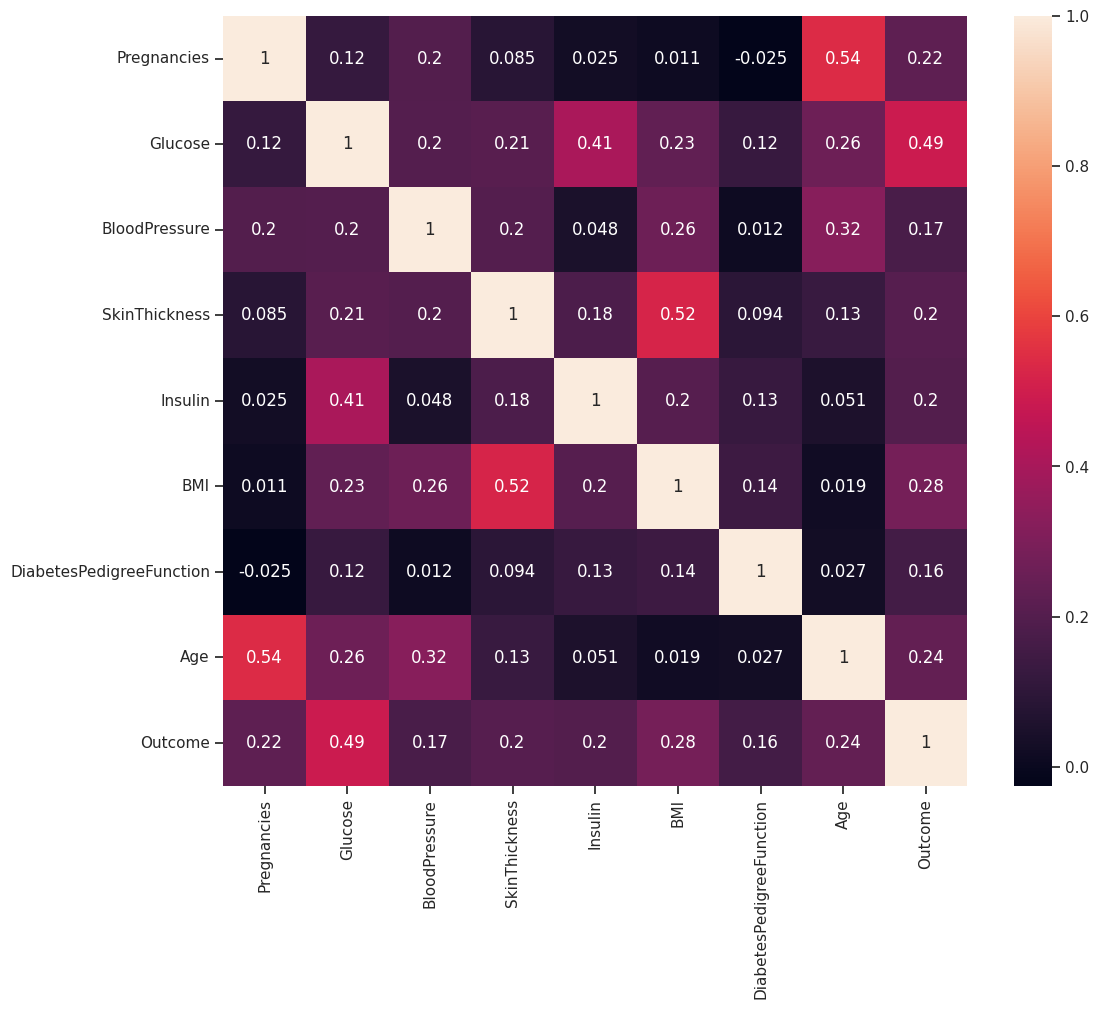

In [119]:
#Correlation Heatmap
plt.figure(figsize = (12,10))
sns.heatmap(df.corr(),annot = True)

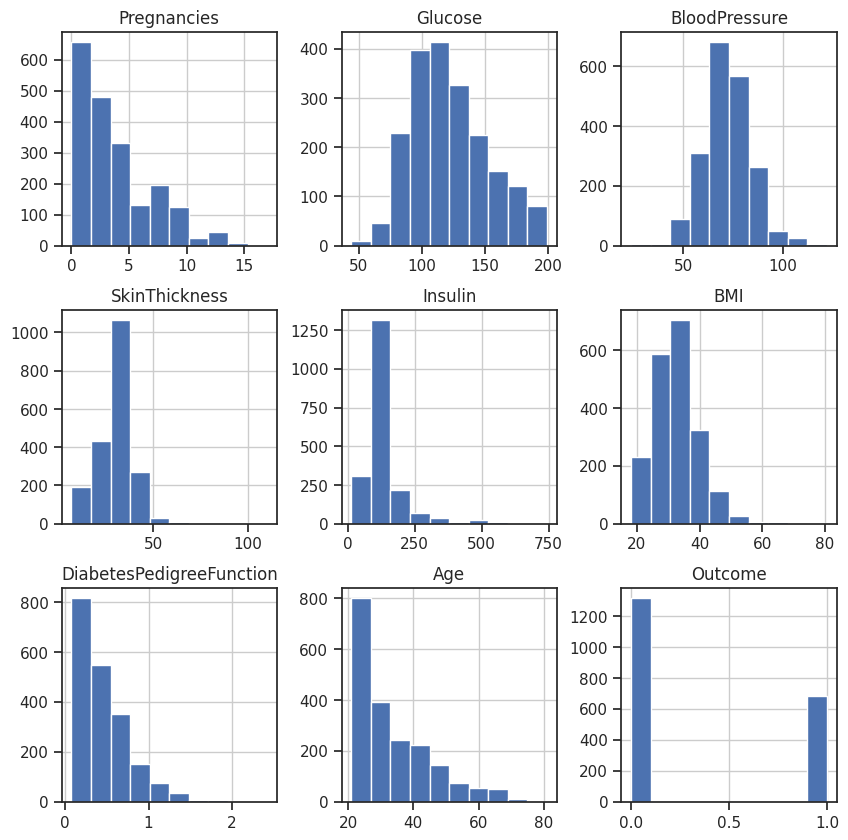

In [120]:
#Histogram
df.hist(figsize = (10,10))
plt.show()

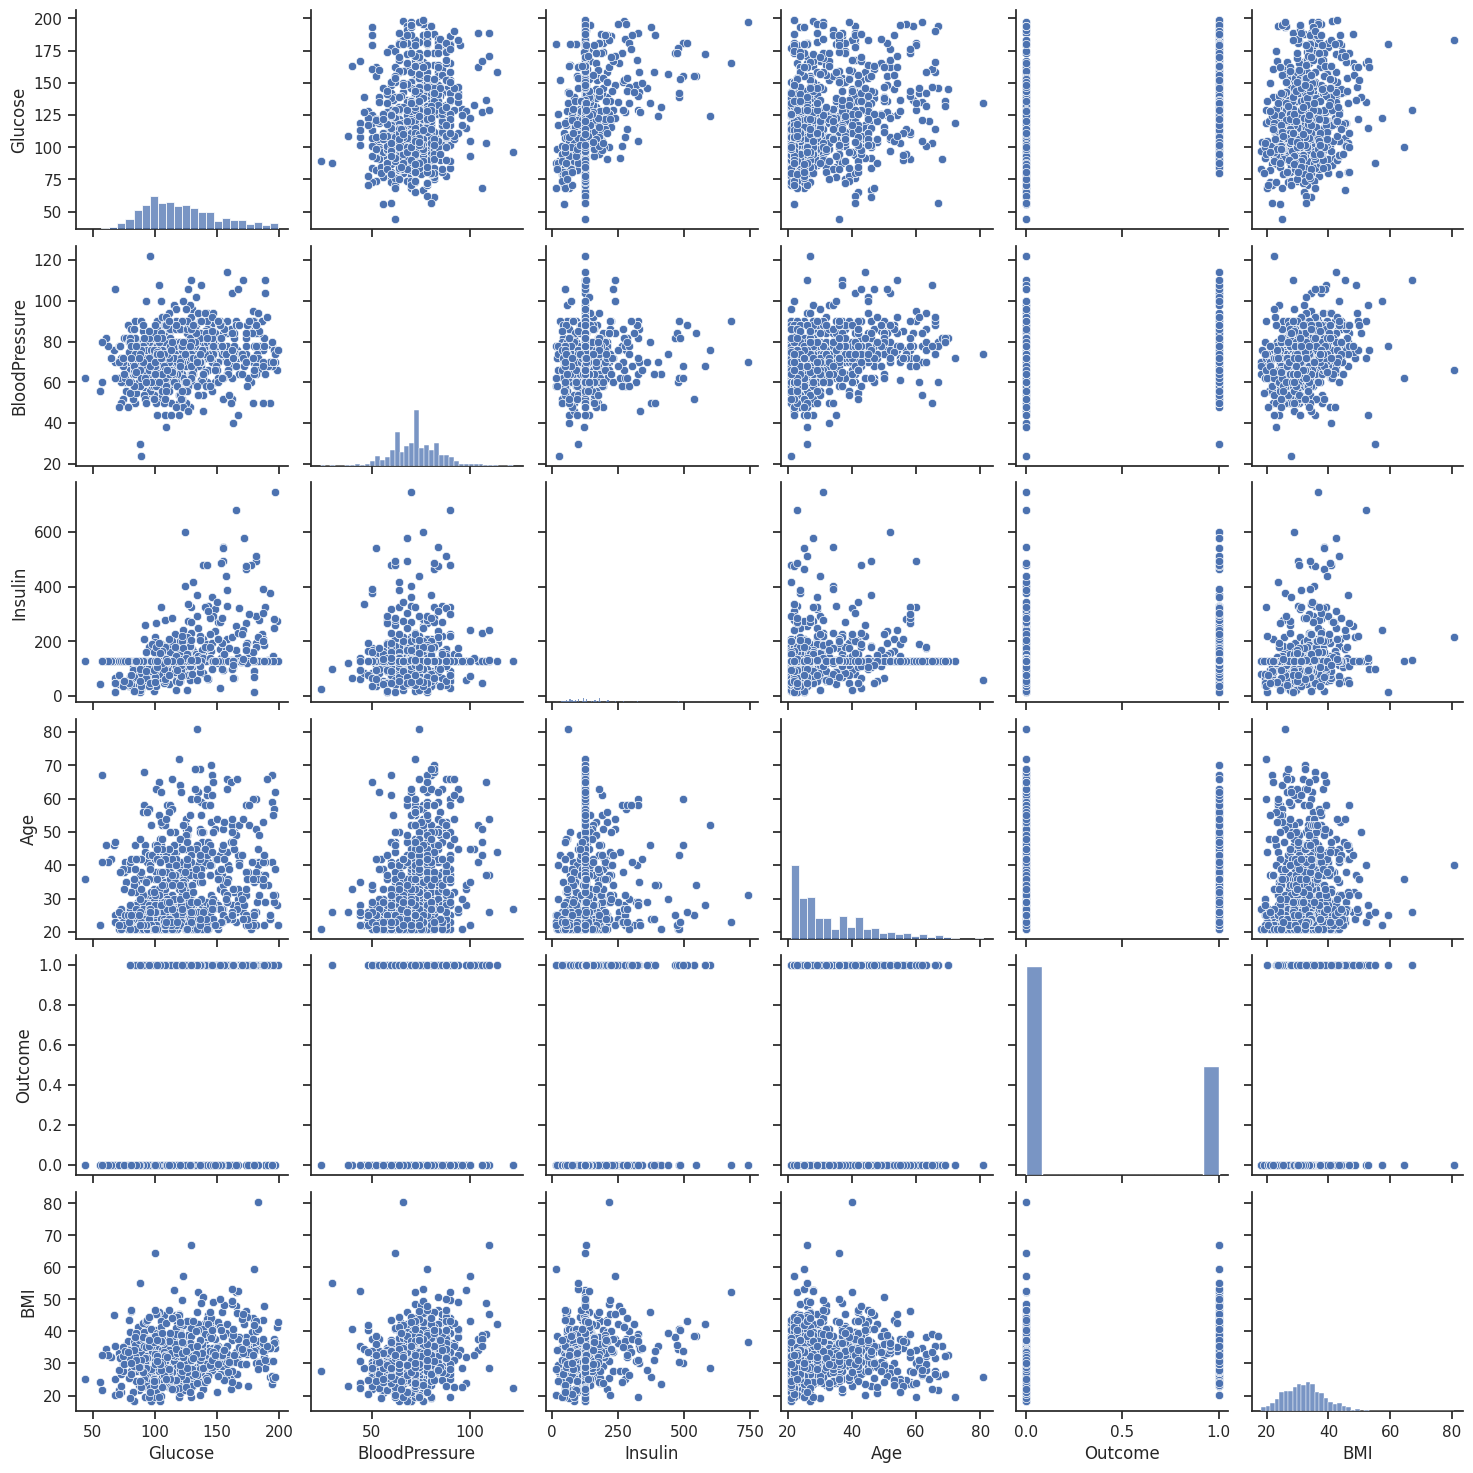

In [121]:
#pairplot
mean_col = ['Glucose','BloodPressure','Insulin','Age','Outcome','BMI']
sns.pairplot(df[mean_col],palette = 'Accent')

<Axes: xlabel='BMI', ylabel='Glucose'>

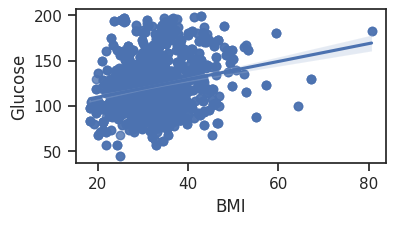

In [122]:
#regplot
sns.regplot(x='BMI',y='Glucose', data=df)

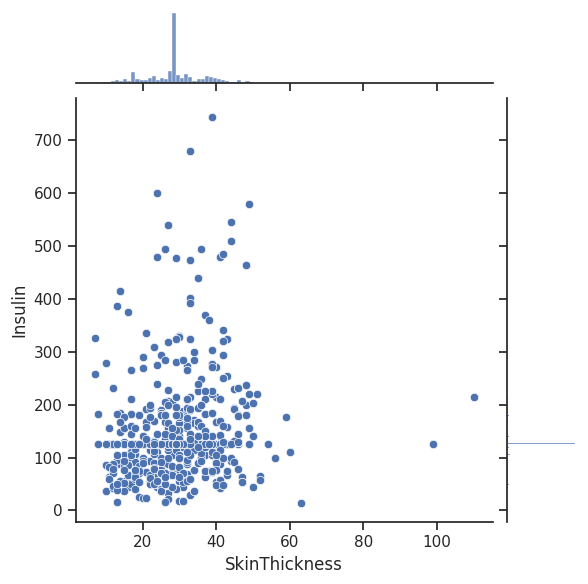

In [123]:
#scatterplot
sns.jointplot(x='SkinThickness', y='Insulin', data=df)

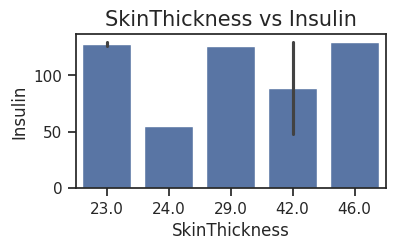

In [124]:
#barplot
sns.barplot(x='SkinThickness', y='Insulin', data=df[170:180])
plt.title("SkinThickness vs Insulin", fontsize=15)
plt.xlabel("SkinThickness")
plt.ylabel("Insulin")
plt.show()
plt.style.use("ggplot")

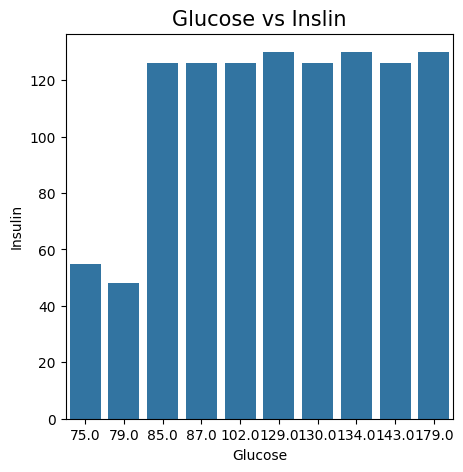

In [125]:
#barplot
plt.style.use("default")
plt.figure(figsize=(5,5))
sns.barplot(x='Glucose', y='Insulin', data=df[170:180])
plt.title("Glucose vs Inslin", fontsize=15)
plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.show()

<Axes: xlabel='Outcome', ylabel='count'>

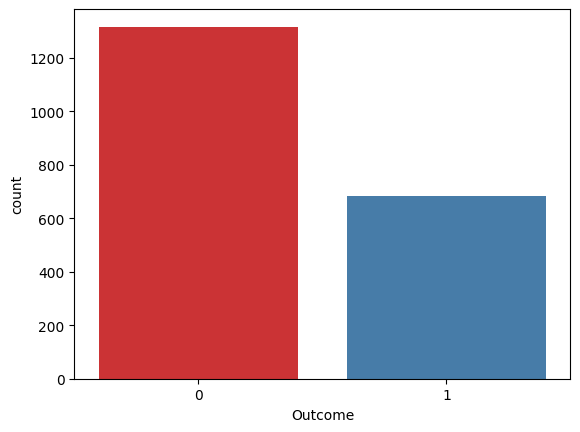

In [126]:
#Count of total outcome in each target 0 1
#0 means no diabetes
#1 means patient with diabetes
sns.countplot(x=df['Outcome'],palette='Set1')

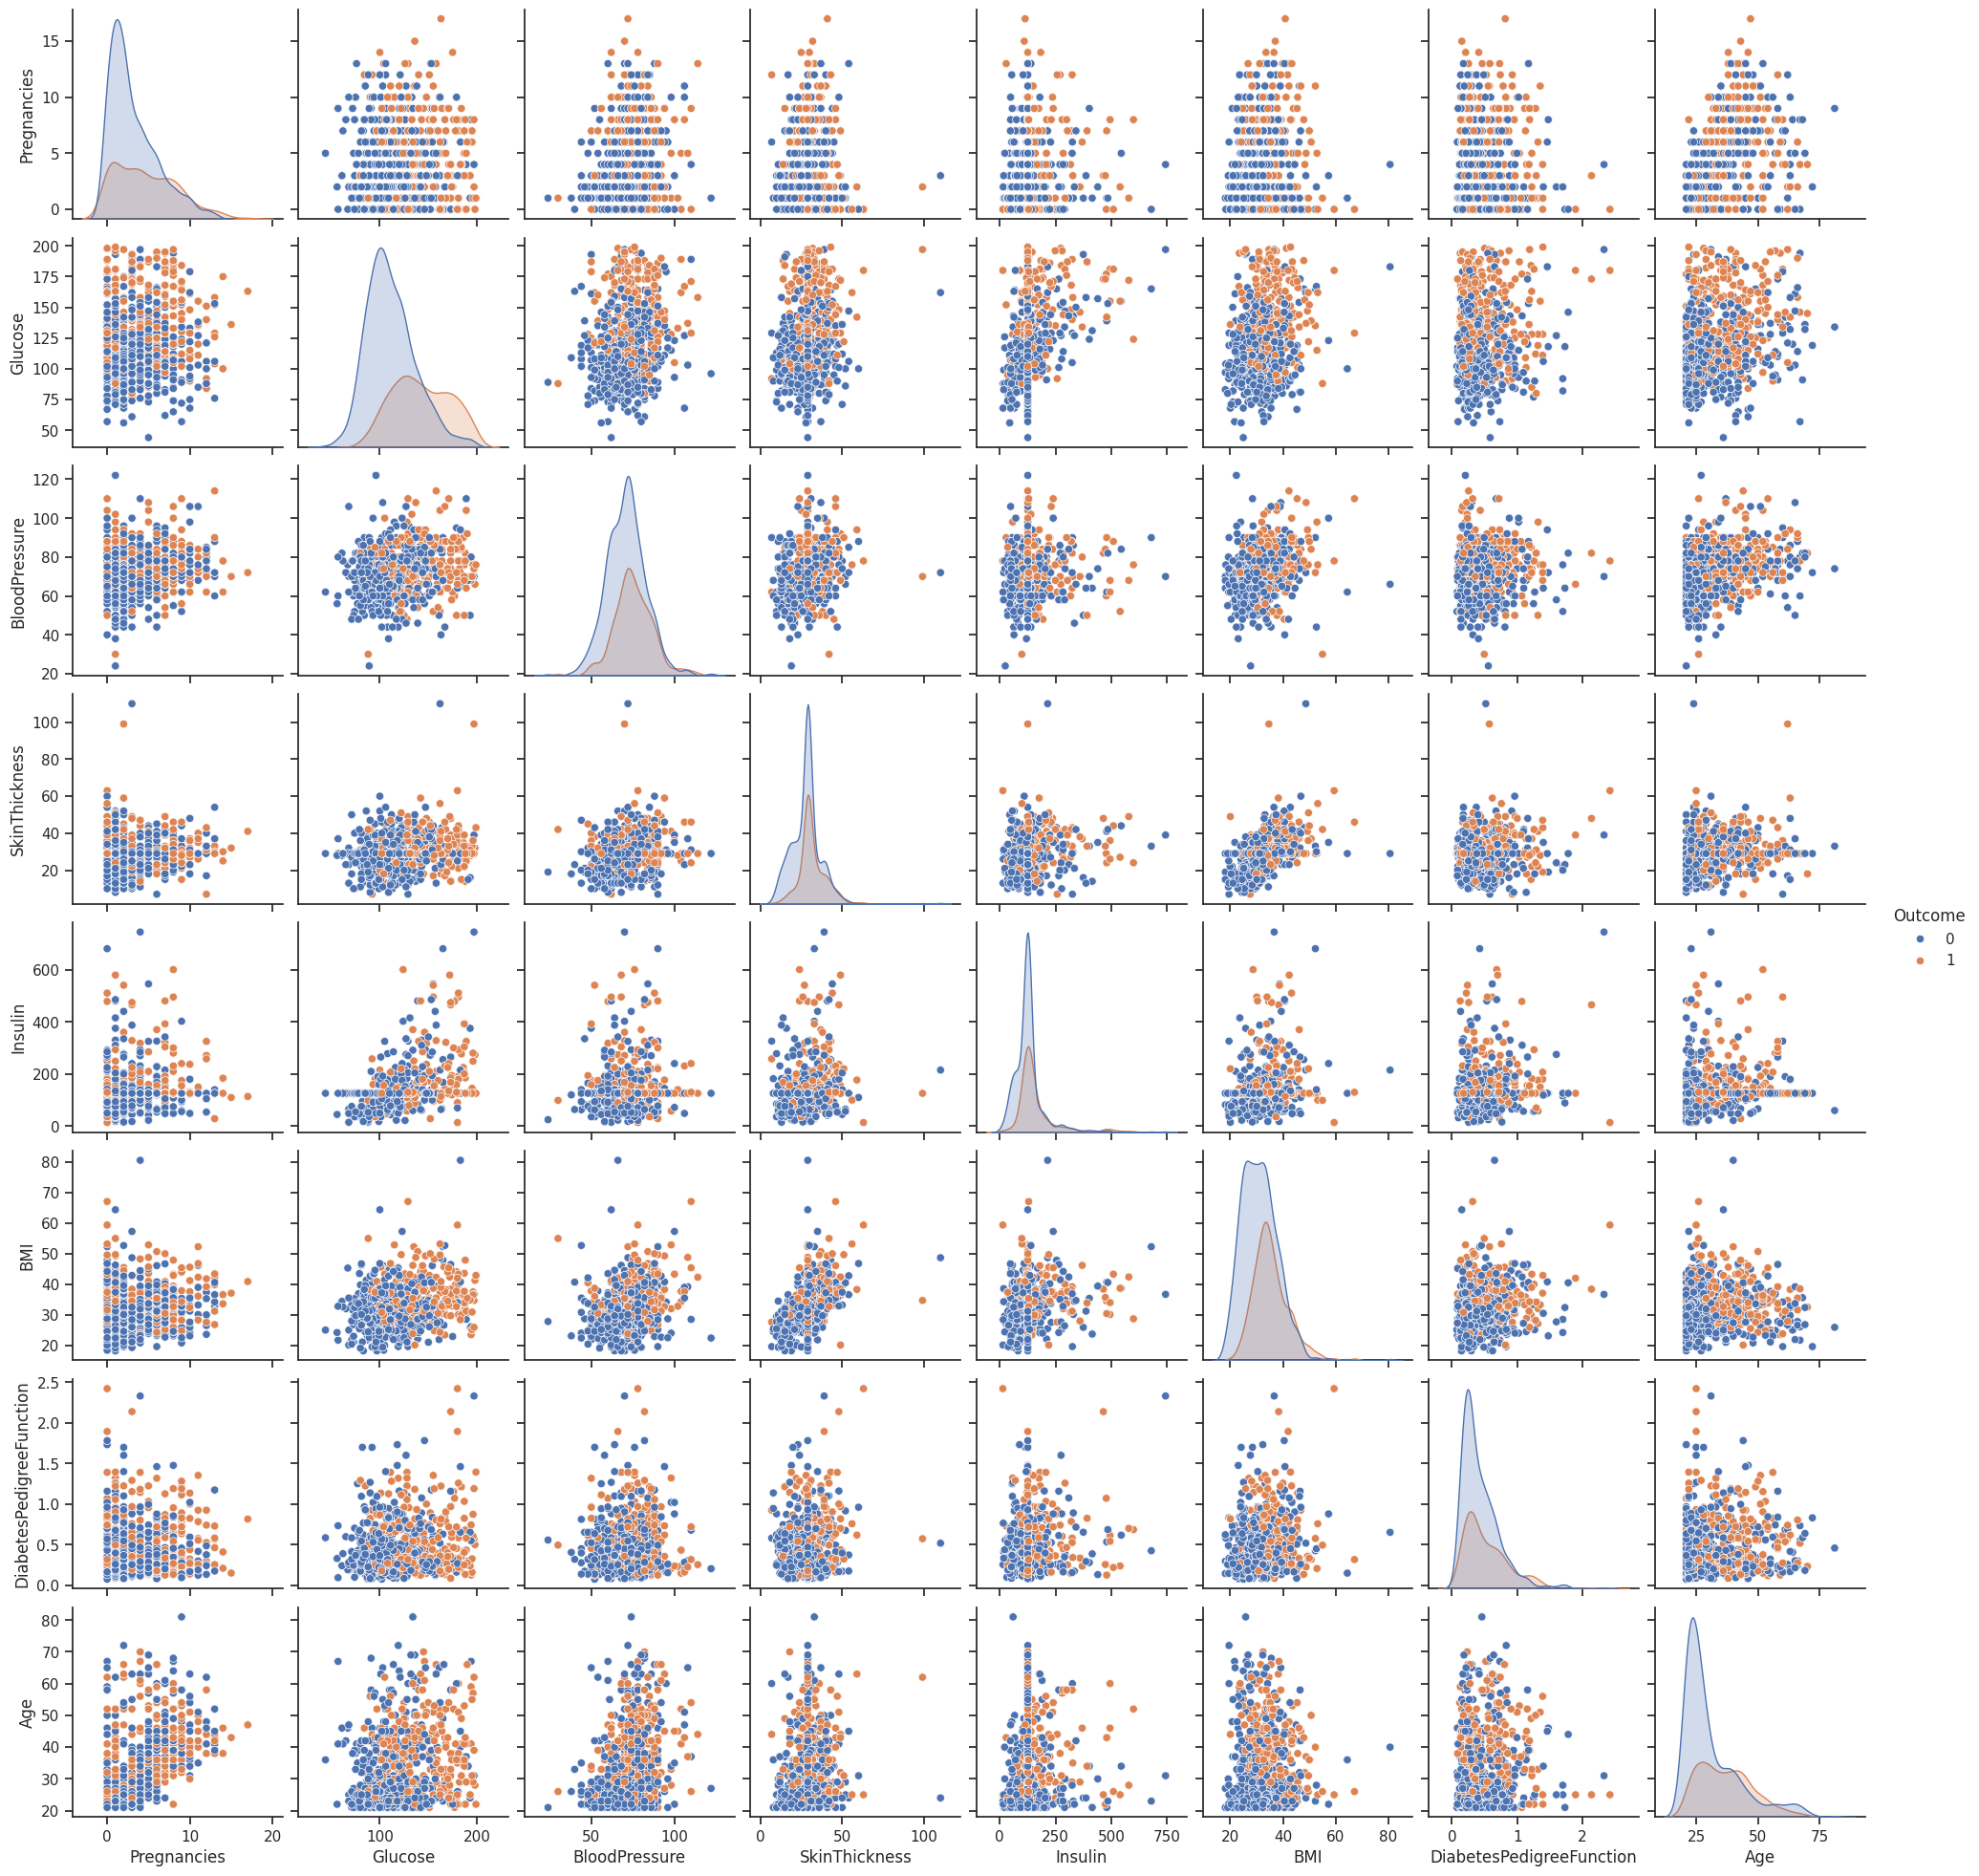

In [127]:
#pairplot
sns.set(style="ticks")
sns.pairplot(df, hue="Outcome")

<Axes: >

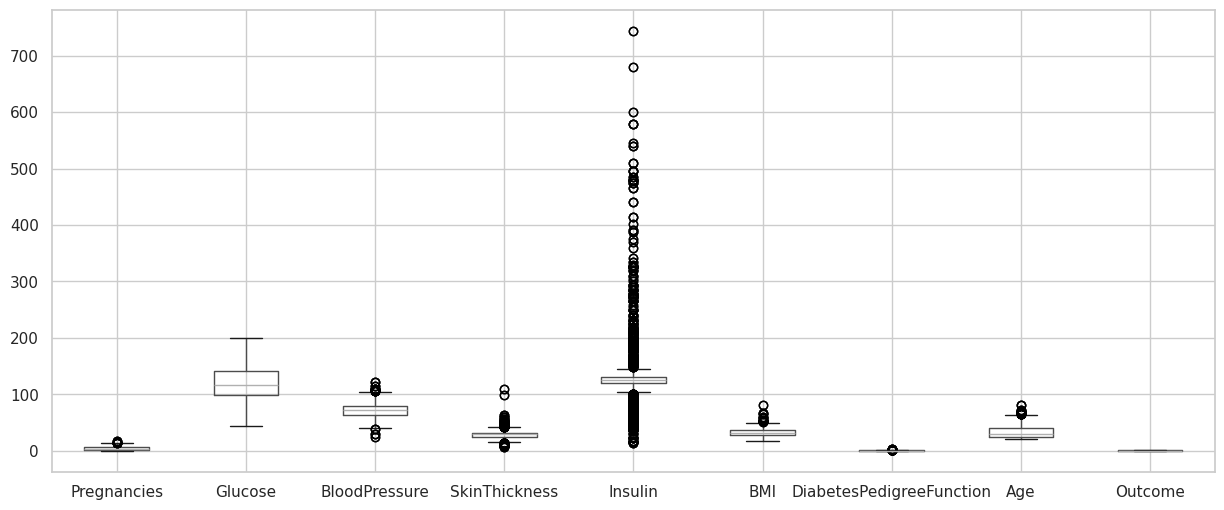

In [128]:
#box plot for outlier visualization
sns.set(style="whitegrid")
df.boxplot(figsize=(15,6))

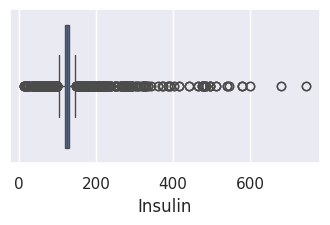

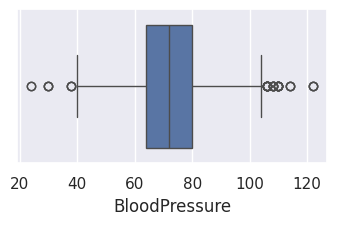

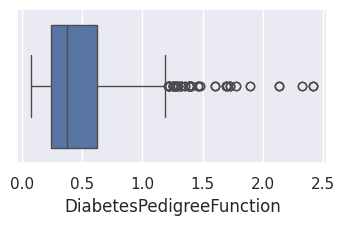

In [129]:
#box plot
sns.set(style="whitegrid")

sns.set(rc={'figure.figsize':(4,2)})
sns.boxplot(x=df['Insulin'])
plt.show()
sns.boxplot(x=df['BloodPressure'])
plt.show()
sns.boxplot(x=df['DiabetesPedigreeFunction'])
plt.show()

In [130]:
#removing outliers

Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1

print("---Q1--- \n",Q1)
print("\n---Q3--- \n",Q3)
print("\n---IQR---\n",IQR)

---Q1--- 
 Pregnancies                   1.000
Glucose                      99.000
BloodPressure                64.000
SkinThickness                25.000
Insulin                     120.000
BMI                          27.600
DiabetesPedigreeFunction      0.244
Age                          24.000
Outcome                       0.000
Name: 0.25, dtype: float64

---Q3--- 
 Pregnancies                   6.000
Glucose                     141.000
BloodPressure                80.000
SkinThickness                32.000
Insulin                     130.000
BMI                          36.800
DiabetesPedigreeFunction      0.624
Age                          40.000
Outcome                       1.000
Name: 0.75, dtype: float64

---IQR---
 Pregnancies                  5.00
Glucose                     42.00
BloodPressure               16.00
SkinThickness                7.00
Insulin                     10.00
BMI                          9.20
DiabetesPedigreeFunction     0.38
Age                      

In [131]:
#Dataframe after removing outliers
df_out = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]
df.shape,df_out.shape

((2000, 9), (1021, 9))

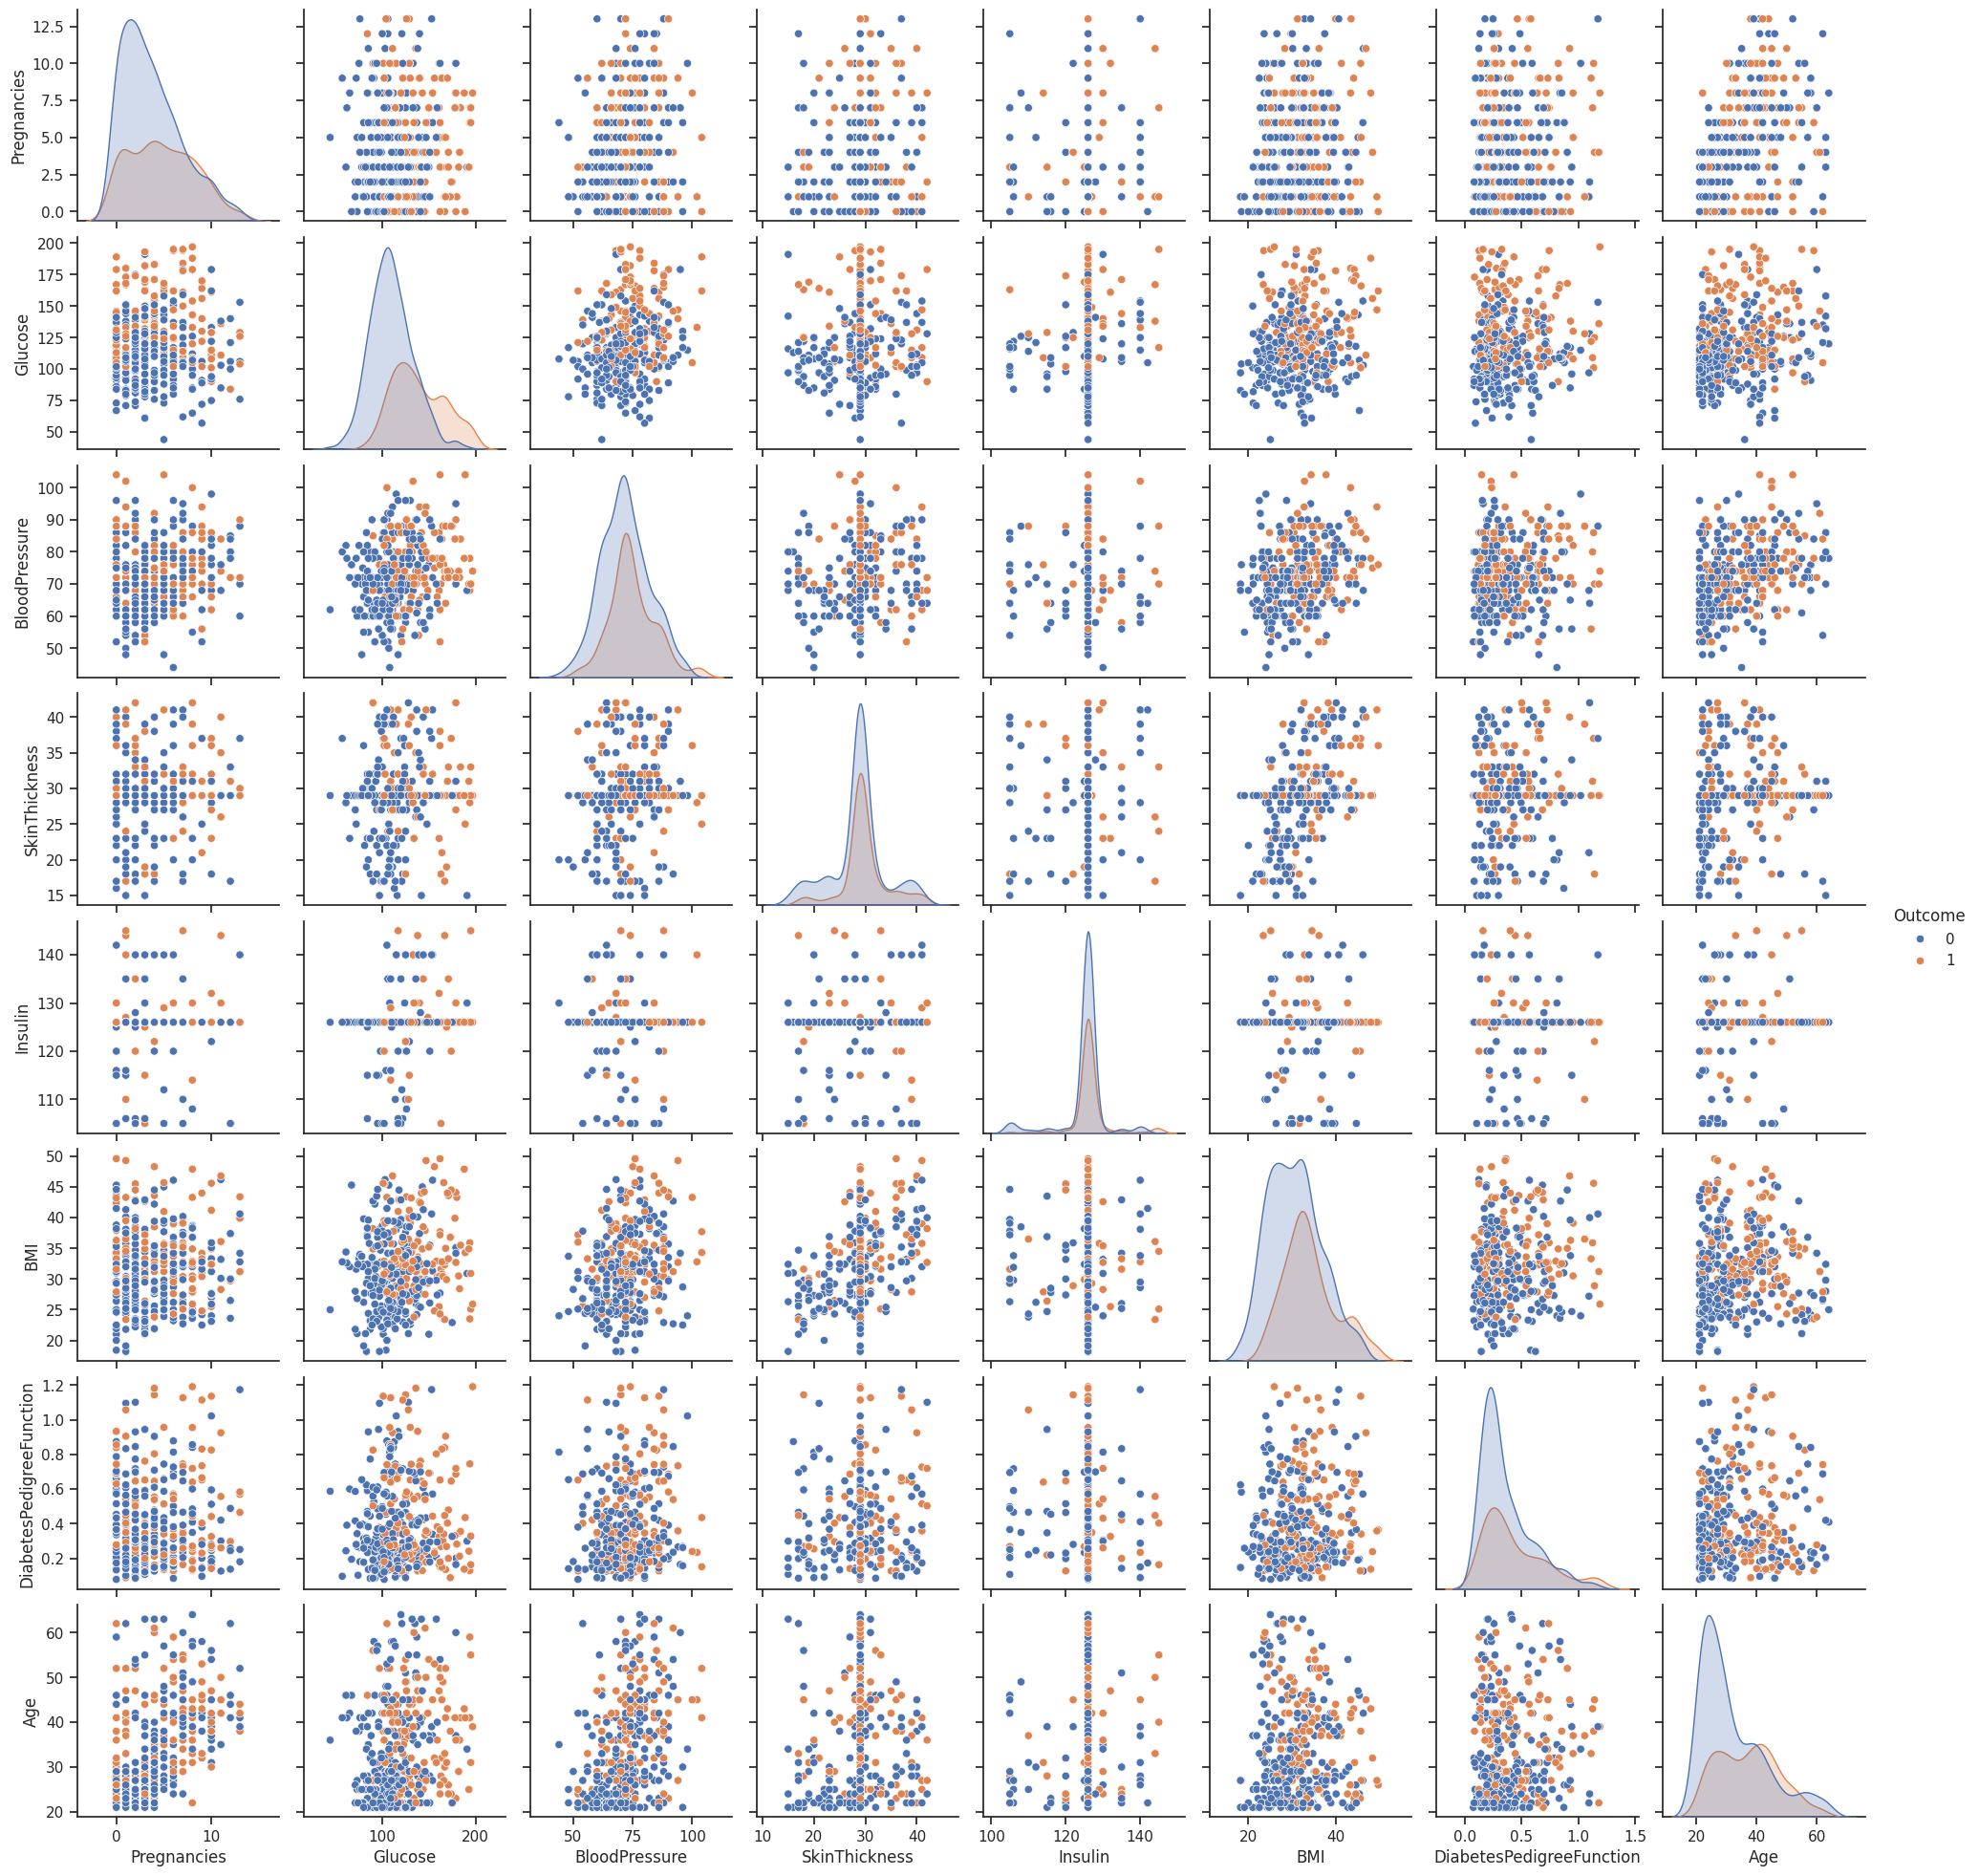

In [132]:
#Scatter matrix after removing outliers
sns.set(style="ticks")
sns.pairplot(df_out, hue="Outcome")
plt.show()

Text(0, 0.5, 'Count of Patients')

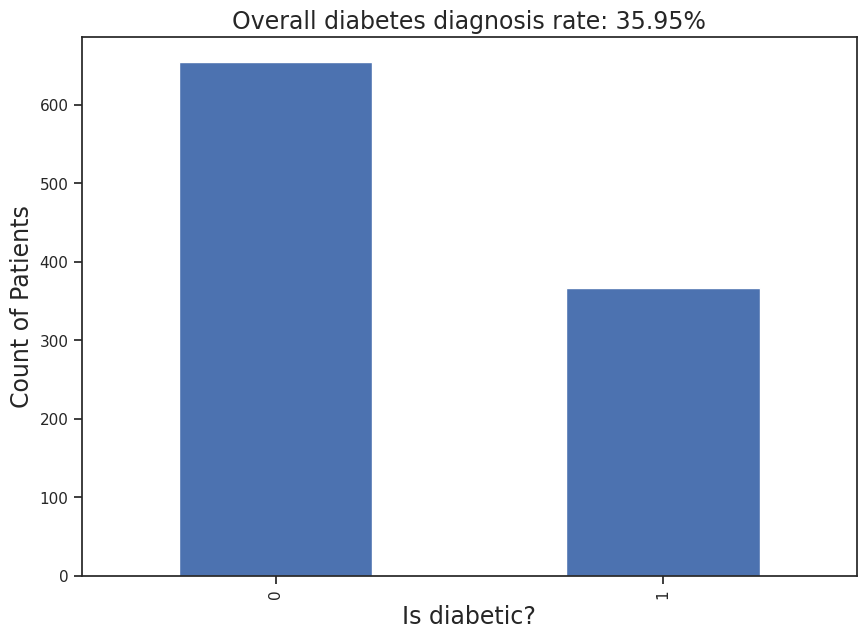

In [133]:
#Visualizing distribution of Y feature (predictive variable)
plt.figure(figsize=(10,7))
df_out.Outcome.value_counts().sort_index().plot.bar()
diabetic_rate = df_out.Outcome.mean()
plt.title(f"Overall diabetes diagnosis rate: {diabetic_rate:.2%}", size=17)
plt.xlabel('Is diabetic?', size=17)
plt.ylabel('Count of Patients', size=17)

# Data Modeling

In [134]:
df.shape

(2000, 9)

In [135]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138.0,62.0,35.0,126.0,33.6,0.127,47,1
1,0,84.0,82.0,31.0,125.0,38.2,0.233,23,0
2,0,145.0,72.0,29.0,126.0,44.2,0.630,31,1
3,0,135.0,68.0,42.0,250.0,42.3,0.365,24,1
4,1,139.0,62.0,41.0,480.0,40.7,0.536,21,0


In [136]:
X=df_out.drop(columns=['Outcome'])
y=df_out['Outcome']

In [137]:
from sklearn.model_selection import train_test_split

In [138]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2)

In [139]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((816, 8), (205, 8), (816,), (205,))

In [195]:
#performing 2-sample z-test
from statsmodels.stats.weightstats import ztest as ztest
ztest(X_train.iloc[:, 5], X_train.iloc[:, 7], value=0)

(np.float64(-5.681134011194884), np.float64(1.3380458171455741e-08))

# Logistic Regression

In [141]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn import metrics

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

param_grid = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'model__solver': ['liblinear', 'lbfgs', 'saga'],  # all support L2
    'model__class_weight': [
        None,
        'balanced'
    ],
    'model__max_iter': [500, 1000, 2000],
    'model__tol': [1e-3, 1e-4, 1e-5],
    'model__penalty': ['l1', 'l2', 'elasticnet']
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='accuracy',
)


In [142]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'model__class_weight': [None, 'balanced'],
                         'model__max_iter': [500, 1000, 2000],
                         'model__penalty': ['l1', 'l2', 'elasticnet'],
                         'model__solver': ['liblinear', 'lbfgs', 'saga'],
                         'model__tol': [0.001, 0.0001, 1e-05]},
             scoring='accuracy')

In [143]:
# Print fold-by-fold test scores along with mean ± standard deviation
for i in range(len(grid.cv_results_["params"])):
    print(f"Params: {grid.cv_results_['params'][i]}")

    # Fold-by-fold scores
    fold_scores = []
    for fold in range(grid.n_splits_):
        score = grid.cv_results_[f'split{fold}_test_score'][i]
        fold_scores.append(score)
        print(f"  Fold {fold} accuracy: {score:.4f}")

    # Compute mean ± standard deviation
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    print(f"  Mean ± Std: {mean_score:.4f} ± {std_score:.4f}")
    print("-" * 40)


Params: {'model__C': 0.001, 'model__class_weight': None, 'model__max_iter': 500, 'model__penalty': 'l1', 'model__solver': 'liblinear', 'model__tol': 0.001}
  Fold 0 accuracy: 0.6402
  Fold 1 accuracy: 0.6380
  Fold 2 accuracy: 0.6380
  Fold 3 accuracy: 0.6380
  Fold 4 accuracy: 0.6442
  Mean ± Std: 0.6397 ± 0.0024
----------------------------------------
Params: {'model__C': 0.001, 'model__class_weight': None, 'model__max_iter': 500, 'model__penalty': 'l1', 'model__solver': 'liblinear', 'model__tol': 0.0001}
  Fold 0 accuracy: 0.6402
  Fold 1 accuracy: 0.6380
  Fold 2 accuracy: 0.6380
  Fold 3 accuracy: 0.6380
  Fold 4 accuracy: 0.6442
  Mean ± Std: 0.6397 ± 0.0024
----------------------------------------
Params: {'model__C': 0.001, 'model__class_weight': None, 'model__max_iter': 500, 'model__penalty': 'l1', 'model__solver': 'liblinear', 'model__tol': 1e-05}
  Fold 0 accuracy: 0.6402
  Fold 1 accuracy: 0.6380
  Fold 2 accuracy: 0.6380
  Fold 3 accuracy: 0.6380
  Fold 4 accuracy: 0.6442

In [144]:
grid.best_params_

{'model__C': 1,
 'model__class_weight': None,
 'model__max_iter': 500,
 'model__penalty': 'l2',
 'model__solver': 'lbfgs',
 'model__tol': 0.001}

In [145]:
log_reg_pred = grid.best_estimator_.predict(X_test)

In [146]:
# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, log_reg_pred)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.8049


In [147]:
# Convert results to a DataFrame
results = pd.DataFrame(grid.cv_results_)

# Compute mean ± std already in cv_results
results['mean ± std'] = results['mean_test_score'].round(4).astype(str) + ' ± ' + results['std_test_score'].round(4).astype(str)

# Sort by rank
results_sorted = results.sort_values(by='rank_test_score').reset_index(drop=True)

# Select relevant columns for table
top_table = results_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(5)  # top 5 rows
top_table.rename(columns={
    'params': 'Parameters',
    'mean_test_score': 'Mean Validation Score',
    'std_test_score': 'Std Dev',
    'rank_test_score': 'Rank'
}, inplace=True)

print(top_table)


                                          Parameters  Mean Validation Score  \
0  {'model__C': 1, 'model__class_weight': None, '...               0.756135   
1  {'model__C': 1, 'model__class_weight': None, '...               0.756135   
2  {'model__C': 1, 'model__class_weight': None, '...               0.756135   
3  {'model__C': 1, 'model__class_weight': None, '...               0.756135   
4  {'model__C': 1, 'model__class_weight': None, '...               0.756135   

    Std Dev  Rank  
0  0.033631     1  
1  0.033631     1  
2  0.033631     1  
3  0.033631     1  
4  0.033631     1  


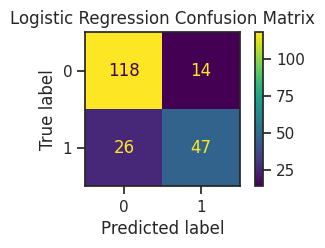

In [148]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(y_test, log_reg_pred)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

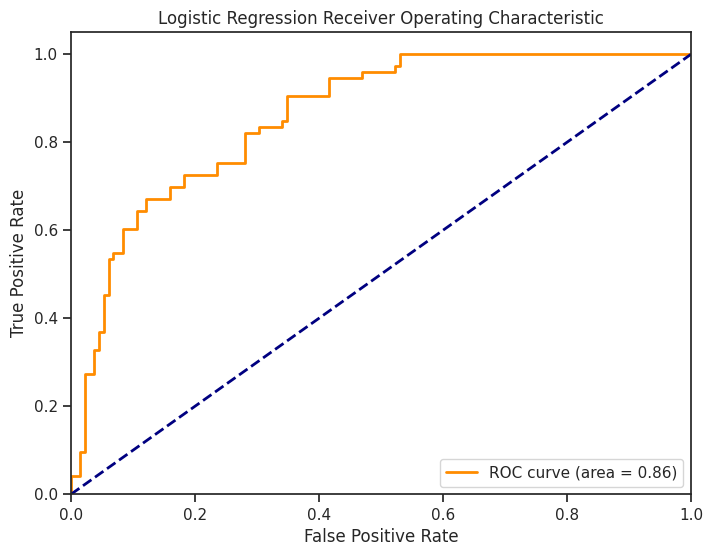

Logistic Regression AUC Score: 0.8605


In [149]:
# Get prediction probabilities for the positive class
log_reg_pred_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, log_reg_pred_proba)
roc_auc = roc_auc_score(y_test, log_reg_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f"Logistic Regression AUC Score: {roc_auc:.4f}")


In [150]:
print(metrics.classification_report(y_test,log_reg_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86       132
           1       0.77      0.64      0.70        73

    accuracy                           0.80       205
   macro avg       0.79      0.77      0.78       205
weighted avg       0.80      0.80      0.80       205



In [151]:
print(grid.best_estimator_.named_steps['model'].coef_)

[[ 0.21977609  1.16584268 -0.15125762  0.12076     0.14296959  0.51903068
   0.32670467  0.27741042]]


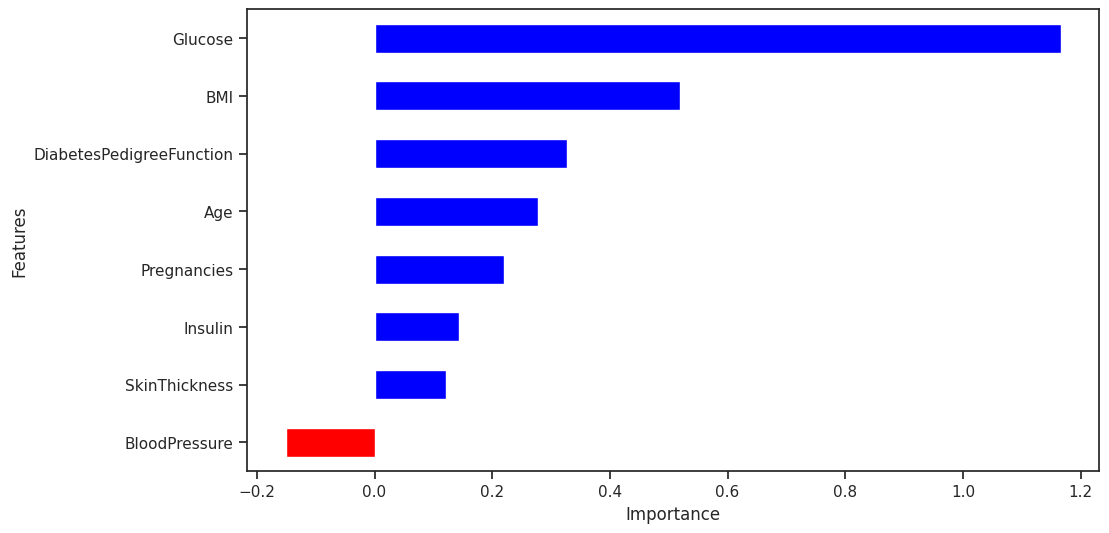

In [152]:
coeff = list(grid.best_estimator_.named_steps['model'].coef_[0])
labels = list(X_test.columns)
features = pd.DataFrame()
features['Features'] = labels
features['importance'] = coeff
features.sort_values(by=['importance'], ascending=True, inplace=True)
features['positive'] = features['importance'] > 0
features.set_index('Features', inplace=True)
features.importance.plot(kind='barh', figsize=(11, 6),color = features.positive.map({True: 'blue', False: 'red'}))
plt.xlabel('Importance');

# SUPPORT VECTOR MACHINE (SVM)

In [153]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns


In [154]:
from sklearn.model_selection import GridSearchCV

In [155]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm_model', SVC(probability=True))
])

param_grid = [
    # linear kernel
    {'svm_model__kernel': ['linear'],
     'svm_model__C': [0.01, 0.1, 1, 100]},

    # rbf kernel
    {'svm_model__kernel': ['rbf'],
     'svm_model__C': [0.01, 0.1, 1, 100],
     'svm_model__gamma': ['scale', 'auto']},

    # poly kernel
    {'svm_model__kernel': ['poly'],
     'svm_model__C': [0.01, 0.1, 1, 100],
     'svm_model__gamma': ['scale', 'auto'],
     'svm_model__degree': [2, 3, 4, 5]}
]

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

In [156]:
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svm_model', SVC(probability=True))]),
             param_grid=[{'svm_model__C': [0.01, 0.1, 1, 100],
                          'svm_model__kernel': ['linear']},
                         {'svm_model__C': [0.01, 0.1, 1, 100],
                          'svm_model__gamma': ['scale', 'auto'],
                          'svm_model__kernel': ['rbf']},
                         {'svm_model__C': [0.01, 0.1, 1, 100],
                          'svm_model__degree': [2, 3, 4, 5],
                          'svm_model__gamma': ['scale', 'auto'],
                          'svm_model__kernel': ['poly']}],
             scoring='accuracy')

In [157]:
# Print fold-by-fold test scores along with mean ± standard deviation
for i in range(len(grid.cv_results_["params"])):
    print(f"Params: {grid.cv_results_['params'][i]}")

    # Fold-by-fold scores
    fold_scores = []
    for fold in range(grid.n_splits_):
        score = grid.cv_results_[f'split{fold}_test_score'][i]
        fold_scores.append(score)
        print(f"  Fold {fold} accuracy: {score:.4f}")

    # Compute mean ± standard deviation
    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    print(f"  Mean ± Std: {mean_score:.4f} ± {std_score:.4f}")
    print("-" * 40)


Params: {'svm_model__C': 0.01, 'svm_model__kernel': 'linear'}
  Fold 0 accuracy: 0.7439
  Fold 1 accuracy: 0.7607
  Fold 2 accuracy: 0.8221
  Fold 3 accuracy: 0.7423
  Fold 4 accuracy: 0.6810
  Mean ± Std: 0.7500 ± 0.0451
----------------------------------------
Params: {'svm_model__C': 0.1, 'svm_model__kernel': 'linear'}
  Fold 0 accuracy: 0.7622
  Fold 1 accuracy: 0.7730
  Fold 2 accuracy: 0.8037
  Fold 3 accuracy: 0.7423
  Fold 4 accuracy: 0.6933
  Mean ± Std: 0.7549 ± 0.0367
----------------------------------------
Params: {'svm_model__C': 1, 'svm_model__kernel': 'linear'}
  Fold 0 accuracy: 0.7622
  Fold 1 accuracy: 0.7607
  Fold 2 accuracy: 0.8098
  Fold 3 accuracy: 0.7485
  Fold 4 accuracy: 0.6933
  Mean ± Std: 0.7549 ± 0.0373
----------------------------------------
Params: {'svm_model__C': 100, 'svm_model__kernel': 'linear'}
  Fold 0 accuracy: 0.7622
  Fold 1 accuracy: 0.7607
  Fold 2 accuracy: 0.8160
  Fold 3 accuracy: 0.7485
  Fold 4 accuracy: 0.6994
  Mean ± Std: 0.7573 ± 0

In [158]:
grid.best_params_

{'svm_model__C': 100, 'svm_model__gamma': 'scale', 'svm_model__kernel': 'rbf'}

In [159]:
svm_pred = grid.best_estimator_.predict(X_test)

In [160]:
# # Calculate and print the accuracy score
accuracy = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {accuracy:.4f}")

SVM Accuracy: 0.9171


In [161]:
# Convert results to a DataFrame
results = pd.DataFrame(grid.cv_results_)

# Compute mean ± std already in cv_results
results['mean ± std'] = results['mean_test_score'].round(4).astype(str) + ' ± ' + results['std_test_score'].round(4).astype(str)

# Sort by rank
results_sorted = results.sort_values(by='rank_test_score').reset_index(drop=True)

# Select relevant columns for table
top_table = results_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(5)  # top 5 rows
top_table.rename(columns={
    'params': 'Parameters',
    'mean_test_score': 'Mean Validation Score',
    'std_test_score': 'Std Dev',
    'rank_test_score': 'Rank'
}, inplace=True)

print(top_table)


                                          Parameters  Mean Validation Score  \
0  {'svm_model__C': 100, 'svm_model__gamma': 'sca...               0.909292   
1  {'svm_model__C': 100, 'svm_model__gamma': 'aut...               0.909292   
2  {'svm_model__C': 100, 'svm_model__degree': 5, ...               0.887236   
3  {'svm_model__C': 100, 'svm_model__degree': 5, ...               0.887236   
4  {'svm_model__C': 100, 'svm_model__degree': 4, ...               0.844314   

    Std Dev  Rank  
0  0.025622     1  
1  0.025622     1  
2  0.024490     3  
3  0.024490     3  
4  0.031842     5  


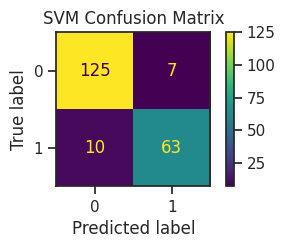

In [162]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)
plt.title('SVM Confusion Matrix')
plt.show()

In [163]:
# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_test, svm_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       132
           1       0.90      0.86      0.88        73

    accuracy                           0.92       205
   macro avg       0.91      0.90      0.91       205
weighted avg       0.92      0.92      0.92       205



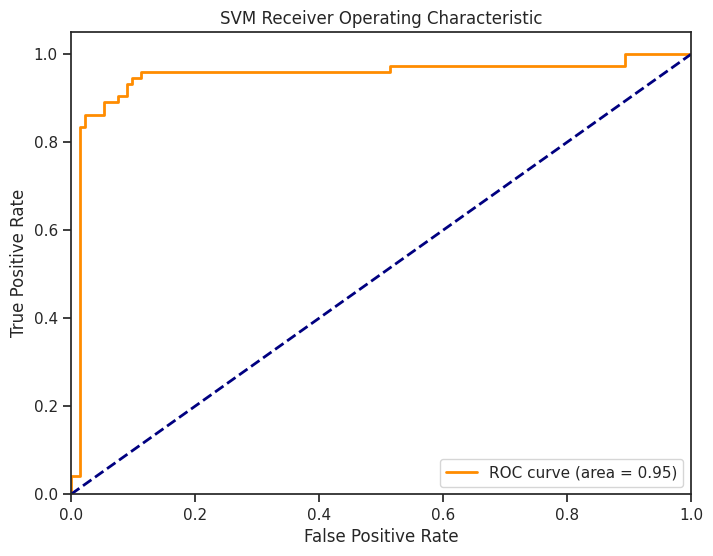

SVM AUC Score: 0.9479


In [164]:
# Get prediction probabilities for the positive class
svm_pred_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, svm_pred_proba)
roc_auc = roc_auc_score(y_test, svm_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f"SVM AUC Score: {roc_auc:.4f}")

# RANDOM FOREST

In [165]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [166]:
from sklearn.model_selection import GridSearchCV

In [167]:
n_estimators=[64,100,128,200]
max_features= [2,3,4]
bootstrap = [True,False]
oob_score = [True,False]

In [168]:
param_grid = {'randomforestclassifier__n_estimators':n_estimators,
             'randomforestclassifier__max_features':max_features,
             'randomforestclassifier__bootstrap':bootstrap,
             'randomforestclassifier__oob_score':oob_score}

In [169]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('randomforestclassifier', RandomForestClassifier())
])

grid = GridSearchCV(pipe, param_grid)

In [170]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             param_grid={'randomforestclassifier__bootstrap': [True, False],
                         'randomforestclassifier__max_features': [2, 3, 4],
                         'randomforestclassifier__n_estimators': [64, 100, 128,
                                                                  200],
                         'randomforestclassifier__oob_score': [True, False]})

In [171]:
grid.best_params_

{'randomforestclassifier__bootstrap': True,
 'randomforestclassifier__max_features': 3,
 'randomforestclassifier__n_estimators': 64,
 'randomforestclassifier__oob_score': False}

In [172]:
rf_pred = grid.predict(X_test)

In [173]:
# The pipeline handles fitting and prediction via the GridSearchCV object
# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.9366


In [174]:
# Convert results to a DataFrame
results = pd.DataFrame(grid.cv_results_)

# Compute mean ± std already in cv_results
results['mean ± std'] = results['mean_test_score'].round(4).astype(str) + ' ± ' + results['std_test_score'].round(4).astype(str)

# Sort by rank
results_sorted = results.sort_values(by='rank_test_score').reset_index(drop=True)

# Select relevant columns for table
top_table = results_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(5)  # top 5 rows
top_table.rename(columns={
    'params': 'Parameters',
    'mean_test_score': 'Mean Validation Score',
    'std_test_score': 'Std Dev',
    'rank_test_score': 'Rank'
}, inplace=True)

# Display
print(top_table)


                                          Parameters  Mean Validation Score  \
0  {'randomforestclassifier__bootstrap': True, 'r...               0.957115   
1  {'randomforestclassifier__bootstrap': True, 'r...               0.957100   
2  {'randomforestclassifier__bootstrap': True, 'r...               0.955866   
3  {'randomforestclassifier__bootstrap': True, 'r...               0.955866   
4  {'randomforestclassifier__bootstrap': True, 'r...               0.954646   

    Std Dev  Rank  
0  0.013964     1  
1  0.014537     2  
2  0.012553     3  
3  0.019581     3  
4  0.015351     5  


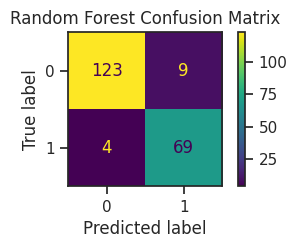

In [175]:
# Visualize Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title('Random Forest Confusion Matrix')
plt.show()

In [176]:
# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95       132
           1       0.88      0.95      0.91        73

    accuracy                           0.94       205
   macro avg       0.93      0.94      0.93       205
weighted avg       0.94      0.94      0.94       205



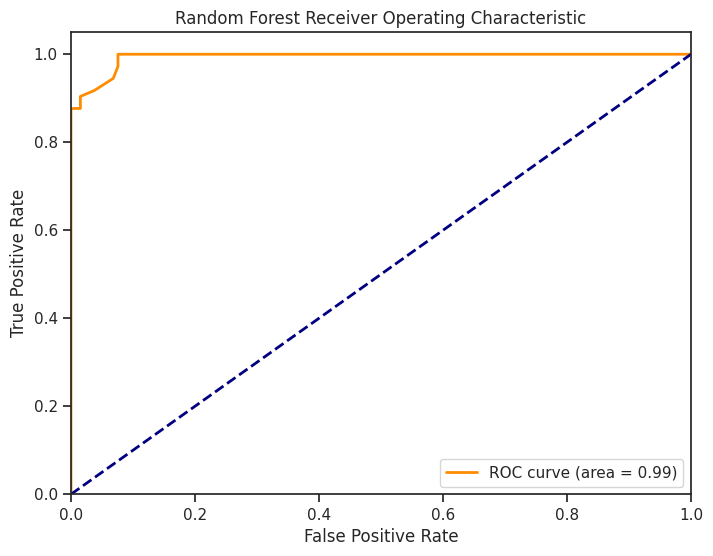

Random Forest AUC Score: 0.9937


In [177]:
# Get prediction probabilities for the positive class
rf_pred_proba = grid.best_estimator_.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_proba)
roc_auc = roc_auc_score(y_test, rf_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f"Random Forest AUC Score: {roc_auc:.4f}")

In [178]:
grid.best_estimator_.named_steps['randomforestclassifier'].feature_importances_

array([0.09368649, 0.30835652, 0.09412188, 0.0673839 , 0.03415599,
       0.15017794, 0.12146542, 0.13065185])

In [179]:
test_error = []
for i in range(1, 40):
    pipeline_temp = Pipeline([
        ('scaler', StandardScaler()),
        ('randomforestclassifier', RandomForestClassifier(n_estimators=i, random_state=42, class_weight='balanced'))
    ])
    pipeline_temp.fit(X_train, y_train)
    rf_pred_temp = pipeline_temp.predict(X_test)
    accuracy_temp = accuracy_score(y_test, rf_pred_temp)
    test_error.append(1 - accuracy_temp)

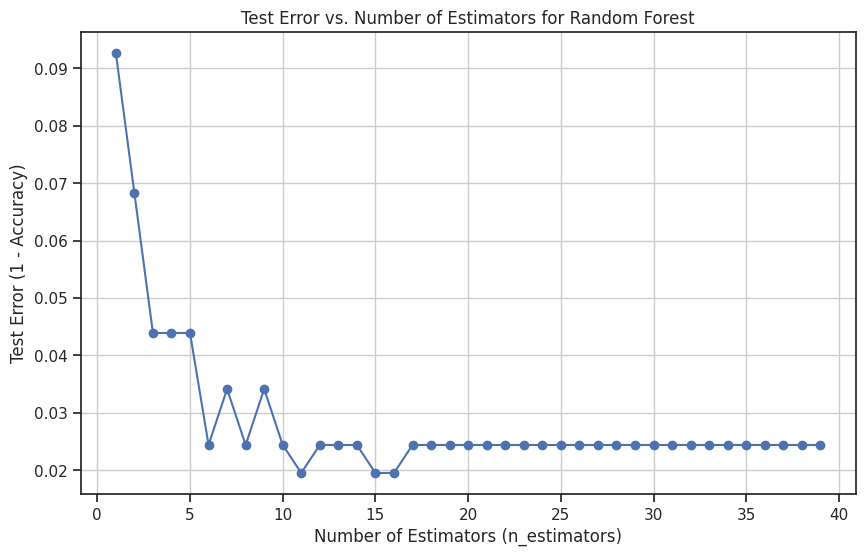

In [180]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), test_error, marker='o', linestyle='-')
plt.title('Test Error vs. Number of Estimators for Random Forest')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Test Error (1 - Accuracy)')
plt.xticks(range(0, 41, 5))
plt.grid(True)
plt.show()

In [181]:
grid.fit(X_train,y_train)

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier())]),
             param_grid={'randomforestclassifier__bootstrap': [True, False],
                         'randomforestclassifier__max_features': [2, 3, 4],
                         'randomforestclassifier__n_estimators': [64, 100, 128,
                                                                  200],
                         'randomforestclassifier__oob_score': [True, False]})

In [182]:
# Print fold-by-fold test scores along with mean ± standard deviation
for i in range(len(grid.cv_results_["params"])):
    print(f"Params: {grid.cv_results_['params'][i]}")

    # Fold-by-fold scores
    fold_scores = []
    for fold in range(grid.n_splits_):
        # Ensure we are accessing the correct key for test score, it's typically 'splitX_test_score'
        score_key = f'split{fold}_test_score'
        if score_key in grid.cv_results_:
            score = grid.cv_results_[score_key][i]
            fold_scores.append(score)
            print(f"  Fold {fold} accuracy: {score:.4f}")
        else:
            print(f"  Warning: {score_key} not found for params index {i}")

    # Compute mean ± standard deviation
    if fold_scores:
        mean_score = np.mean(fold_scores)
        std_score = np.std(fold_scores)
        print(f"  Mean ± Std: {mean_score:.4f} ± {std_score:.4f}")
    else:
        print("  No fold scores found.")
    print("-" * 40)

Params: {'randomforestclassifier__bootstrap': True, 'randomforestclassifier__max_features': 2, 'randomforestclassifier__n_estimators': 64, 'randomforestclassifier__oob_score': True}
  Fold 0 accuracy: 0.9573
  Fold 1 accuracy: 0.9325
  Fold 2 accuracy: 0.9632
  Fold 3 accuracy: 0.9448
  Fold 4 accuracy: 0.9387
  Mean ± Std: 0.9473 ± 0.0114
----------------------------------------
Params: {'randomforestclassifier__bootstrap': True, 'randomforestclassifier__max_features': 2, 'randomforestclassifier__n_estimators': 64, 'randomforestclassifier__oob_score': False}
  Fold 0 accuracy: 0.9695
  Fold 1 accuracy: 0.9264
  Fold 2 accuracy: 0.9755
  Fold 3 accuracy: 0.9448
  Fold 4 accuracy: 0.9693
  Mean ± Std: 0.9571 ± 0.0186
----------------------------------------
Params: {'randomforestclassifier__bootstrap': True, 'randomforestclassifier__max_features': 2, 'randomforestclassifier__n_estimators': 100, 'randomforestclassifier__oob_score': True}
  Fold 0 accuracy: 0.9634
  Fold 1 accuracy: 0.932

In [183]:
grid.best_params_

{'randomforestclassifier__bootstrap': True,
 'randomforestclassifier__max_features': 2,
 'randomforestclassifier__n_estimators': 64,
 'randomforestclassifier__oob_score': False}

In [184]:
rf_pred = grid.predict(X_test)

In [185]:
# Make predictions on the test set
rf_pred = grid.predict(X_test)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

Random Forest Accuracy: 0.9561


In [186]:
# Convert results to a DataFrame
results = pd.DataFrame(grid.cv_results_)

# Compute mean ± std already in cv_results
results['mean \u00b1 std'] = results['mean_test_score'].round(4).astype(str) + ' \u00b1 ' + results['std_test_score'].round(4).astype(str)

# Sort by rank
results_sorted = results.sort_values(by='rank_test_score').reset_index(drop=True)

# Select relevant columns for table
top_table = results_sorted[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(5)  # top 5 rows
top_table.rename(columns={
    'params': 'Parameters',
    'mean_test_score': 'Mean Validation Score',
    'std_test_score': 'Std Dev',
    'rank_test_score': 'Rank'
}, inplace=True)

display(top_table)

,Parameters,Mean Validation Score,Std Dev,Rank
0,"{'randomforestclassifier__bootstrap': True, 'r...",0.957093,0.018633,1
1,"{'randomforestclassifier__bootstrap': True, 'r...",0.955866,0.013139,2
2,"{'randomforestclassifier__bootstrap': True, 'r...",0.954639,0.013813,3
3,"{'randomforestclassifier__bootstrap': True, 'r...",0.953419,0.017636,4
4,"{'randomforestclassifier__bootstrap': True, 'r...",0.953412,0.017645,5


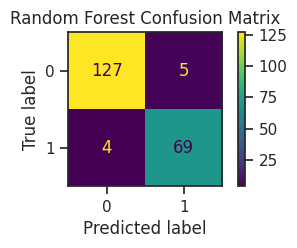

In [187]:
# Visualize Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title('Random Forest Confusion Matrix')
plt.show()

In [188]:
# Print Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       132
           1       0.93      0.95      0.94        73

    accuracy                           0.96       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.96      0.96      0.96       205



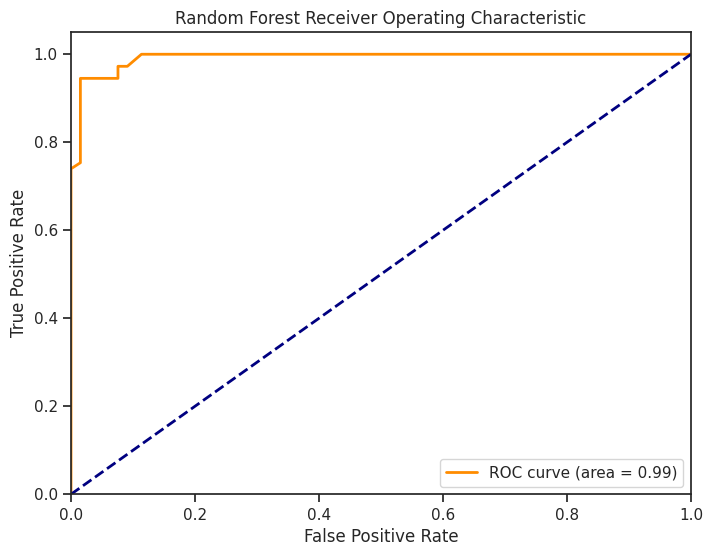

Random Forest AUC Score: 0.9921


In [189]:
# Get prediction probabilities for the positive class
rf_pred_proba = grid.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_proba)
roc_auc = roc_auc_score(y_test, rf_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

print(f"Random Forest AUC Score: {roc_auc:.4f}")

In [190]:
grid.best_estimator_.named_steps['randomforestclassifier'].feature_importances_

array([0.08701516, 0.28103923, 0.10568814, 0.06471017, 0.03936659,
       0.15465405, 0.12677157, 0.1407551 ])

In [191]:
test_error = []
for i in range(1, 40):
    pipeline_temp = Pipeline([
        ('scaler', StandardScaler()),
        ('randomforestclassifier', RandomForestClassifier(n_estimators=i, random_state=42, class_weight='balanced'))
    ])
    pipeline_temp.fit(X_train, y_train)
    rf_pred_temp = pipeline_temp.predict(X_test)
    accuracy_temp = accuracy_score(y_test, rf_pred_temp)
    test_error.append(1 - accuracy_temp)

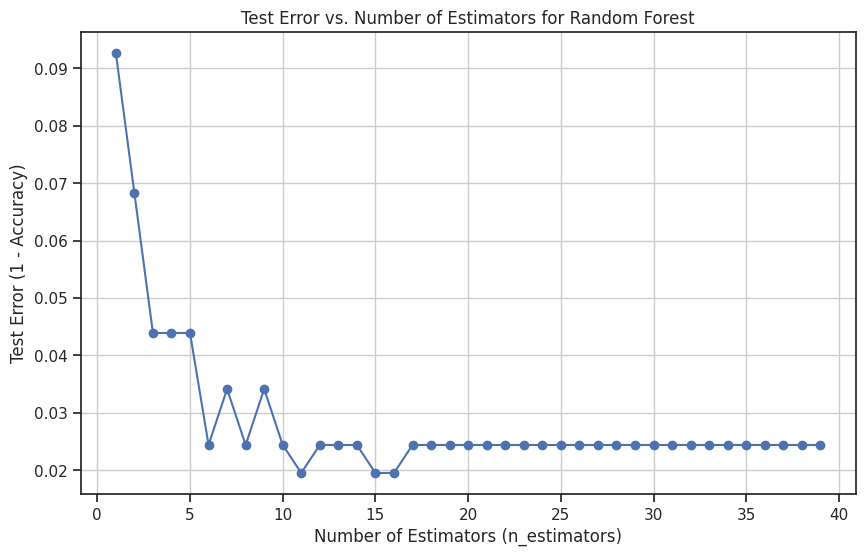

In [192]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 40), test_error, marker='o', linestyle='-')
plt.title('Test Error vs. Number of Estimators for Random Forest')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Test Error (1 - Accuracy)')
plt.xticks(range(0, 41, 5))
plt.grid(True)
plt.show()